<a href="https://colab.research.google.com/github/DaveD-BU/DX-703-FinalProject/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###A.1: Setup and Context

#### Summary of Milestones 1 and 2

##### Data Cleaning and Preprocessing

Across Milestones 1 and 2, we developed and refined a complete preprocessing pipeline for the dataset. Initial efforts focused on identifying missing or inconsistent entries, removing duplicated records, and standardizing all text fields. We applied normalization steps (lowercasing, punctuation removal, whitespace cleanup) and resolved noisy elements such as malformed strings or overly rare tokens. These early cleaning steps established a stable foundation for downstream modeling and reduced variability across samples.

##### Feature Engineering and Augmentation

In Milestone 1, we explored several forms of feature preparation, including tokenization strategies, vocabulary curation, and transformation of raw text into machine-learning–ready representations. We experimented with TF-IDF vectors, early embedding attempts, and basic dimensionality reduction techniques. By Milestone 2, we expanded the pipeline with more expressive features,such as pretrained embeddings and structured augmentation strategies, that improved model stability and representation quality. These refinements helped reveal which features contributed most to class separation and downstream performance.

##### Early Model Experiments (Milestone 2) & Key Learnings

Milestone 2 introduced the first round of modeling experiments, where we evaluated baseline and intermediate architectures to understand dataset difficulty and the impact of preprocessing choices. Simpler models (e.g., TF-IDF + linear classifiers or shallow networks) established initial performance ranges, revealing sensitivity to class imbalance and feature sparsity. More advanced models incorporating pretrained layers achieved higher validation metrics but also surfaced important challenges, such as overfitting, instability with long sequences, and sensitivity to hyperparameters.
These experiments shaped our final pipeline by helping us identify which preprocessing steps had the greatest effect on performance, which architectures generalized best, and which hyperparameters would be prioritized in the final model selection.

In [1]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter
import seaborn as sns
import re

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)
from tensorflow.keras.layers import TextVectorization

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
)

# Import train test split
from sklearn.model_selection import train_test_split

# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


Pandas version: 2.2.2
NumPy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


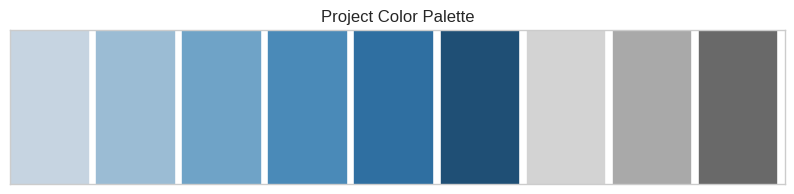

In [2]:
# Define color palette according to project standards
COLOR_PALETTE = [
    "#c6d4e1",  # light blue-grey
    "#9bbcd4",  # soft blue
    "#6fa3c7",  # medium blue
    "#4a8ab8",  # strong blue
    "#2f6fa1",  # deep blue
    "#1f4f75",  # navy
    "#d3d3d3",  # light grey
    "#a9a9a9",  # medium grey
    "#696969",  # dark grey
]

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(COLOR_PALETTE)

# Display versions
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

# Display color palette
plt.figure(figsize=(10, 2))
for i, color in enumerate(COLOR_PALETTE):
    plt.fill_between([i, i+0.9], 0, 1, color=color)
plt.xlim(0, len(COLOR_PALETTE))
plt.ylim(0, 1)
plt.title('Project Color Palette')
plt.xticks([])
plt.yticks([])
plt.show()

In [3]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

#### Load the Data

In [4]:
# Load HuffPost dataset from JSON
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")
print(f"Total samples: {len(huff_all)}")
print(f"Features: {huff_all.column_names}")

# Display example entry
print("\nEntry example:")
example = huff_all[0]
for key, value in example.items():
    display_value = str(value)[:100] + "..." if len(str(value)) > 100 else value
    print(f"  {key}: {display_value}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Total samples: 200853
Features: ['category', 'headline', 'authors', 'link', 'short_description', 'date']

Entry example:
  category: CRIME
  headline: There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors: Melissa Jeltsen
  link: https://www.huffingtonpost.com/entry/texas-amanda-painter-mass-shooting_us_5b081ab4e4b0802d69caad89
  short_description: She left her husband. He killed their children. Just another day in America.
  date: 2018-05-26 00:00:00


#### Apply Cleaning and Normalization

In [5]:
# Remove samples with missing headlines (we found 6 in Milestone 1)
# Filter out samples with missing or empty headlines
initial_count = len(huff_all)
huff_cleaned = huff_all.filter(lambda ex: ex['headline'] and ex['headline'].strip())

removed_count = initial_count - len(huff_cleaned)
print(f"Samples before: {initial_count}")
print(f"Samples after: {len(huff_cleaned)}")
print(f"Removed: {removed_count} samples with missing headlines")

Filter:   0%|          | 0/200853 [00:00<?, ? examples/s]

Samples before: 200853
Samples after: 200847
Removed: 6 samples with missing headlines


In [6]:
# Remove duplicate samples (identified 488 in Milestone 1)
# Create combined text for duplicate detection
def create_combined_text(example):
    headline = example['headline'] or ""
    description = example['short_description'] or ""
    return headline + " [SEP] " + description

# Track seen texts and filter duplicates
seen_texts = set()
def is_not_duplicate(example):
    combined = create_combined_text(example)
    if combined in seen_texts:
        return False
    seen_texts.add(combined)
    return True

initial_count = len(huff_cleaned)
huff_cleaned = huff_cleaned.filter(is_not_duplicate)

removed_count = initial_count - len(huff_cleaned)
print(f"Samples before: {initial_count}")
print(f"Samples after: {len(huff_cleaned)}")
print(f"Removed: {removed_count} duplicate samples")

Filter:   0%|          | 0/200847 [00:00<?, ? examples/s]

Samples before: 200847
Samples after: 200363
Removed: 484 duplicate samples


Taking into account the findings from Milestones 1 and 2, we need to address class imbalance and label ambiguity. Several categories such as GOOD NEWS, WORLD NEWS, LATINO VOICES, TASTE, and FIFTY remain difficult for all architectures due to low support and overlapping semantics with larger sections.

To mitigate these issues, we will implement a label merging strategy that consolidates these challenging categories into more robust super-categories. This approach aims to improve model performance by reducing the complexity and sparsity of the label space.



In [7]:
# === Label merging for overlapping / low-support categories ===
# Based on confusion analysis and semantic overlap

label_merge_map = {
    # Arts / Culture cluster
    'ARTS': 'ARTS',
    'ARTS & CULTURE': 'ARTS',
    'CULTURE & ARTS': 'ARTS',

    # World / WorldPost cluster
    'WORLDPOST': 'WORLDPOST',
    'THE WORLDPOST': 'WORLDPOST',
    'WORLD NEWS': 'WORLDPOST',        # merge low-support WORLD NEWS into WORLDPOST

    # Wellness / Good News cluster
    'WELLNESS': 'WELLNESS',
    'HEALTHY LIVING': 'WELLNESS',
    'GOOD NEWS': 'WELLNESS',          # overlap with WELLNESS / positive lifestyle content

    # Parenting / Family life cluster
    'PARENTS': 'PARENTING',
    'PARENTING': 'PARENTING',
    'FIFTY': 'PARENTING',             # often overlaps with family / life-stage content

    # Style / Lifestyle cluster
    'STYLE': 'STYLE',
    'STYLE & BEAUTY': 'STYLE',

    # Food cluster
    'TASTE': 'FOOD & DRINK',          # merge food-focused vertical into FOOD & DRINK

    # Latino Voices → broader impact / politics cluster
    'LATINO VOICES': 'IMPACT',        # merge into a broader social-impact section
}


def merge_labels(example):
    """
    Merge fine-grained or overlapping HuffPost categories into
    a smaller set of more robust super-categories.
    """
    original_label = example['category']
    merged_label = label_merge_map.get(original_label, original_label)
    example['category'] = merged_label
    return example


# Pretty-print the actual merges we are performing
print("Label Merging Map (only changed labels shown):")
merged_pairs = {k: v for k, v in label_merge_map.items() if k != v}
for original, merged in sorted(merged_pairs.items()):
    print(f"  {original:20s} -> {merged}")
print()

# Apply label merging to the dataset
huff_cleaned = huff_cleaned.map(merge_labels)

# Verify category reduction
unique_categories = sorted(set(huff_cleaned['category']))
print(f"Categories after merging: {len(unique_categories)}")
print(f"Categories reduced from 41 to {len(unique_categories)}")


Label Merging Map (only changed labels shown):
  ARTS & CULTURE       -> ARTS
  CULTURE & ARTS       -> ARTS
  FIFTY                -> PARENTING
  GOOD NEWS            -> WELLNESS
  HEALTHY LIVING       -> WELLNESS
  LATINO VOICES        -> IMPACT
  PARENTS              -> PARENTING
  STYLE & BEAUTY       -> STYLE
  TASTE                -> FOOD & DRINK
  THE WORLDPOST        -> WORLDPOST
  WORLD NEWS           -> WORLDPOST



Map:   0%|          | 0/200363 [00:00<?, ? examples/s]

Categories after merging: 30
Categories reduced from 41 to 30


In [8]:
# Concatenate headline and short_description with [SEP] token

def add_combined_text(example):
    headline = (example['headline'] or "").strip()
    description = (example['short_description'] or "").strip()

    # Combine with [SEP] token
    combined = f"{headline} [SEP] {description}"
    example['text'] = combined

    return example

huff_cleaned = huff_cleaned.map(add_combined_text)

print("Added 'text' field combining headline and description")
print("\nExample of combined texts:")
for i in range(3):
    print(f"\n{i+1}. Category: {huff_cleaned[i]['category']}")
    print(f"   Text: {huff_cleaned[i]['text'][:150]}...")

Map:   0%|          | 0/200363 [00:00<?, ? examples/s]

Added 'text' field combining headline and description

Example of combined texts:

1. Category: CRIME
   Text: There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV [SEP] She left her husband. He killed their children. Just another day in America....

2. Category: ENTERTAINMENT
   Text: Will Smith Joins Diplo And Nicky Jam For The 2018 World Cup's Official Song [SEP] Of course it has a song....

3. Category: ENTERTAINMENT
   Text: Hugh Grant Marries For The First Time At Age 57 [SEP] The actor and his longtime girlfriend Anna Eberstein tied the knot in a civil ceremony....


In [9]:
# Normalize the text (lowercase and stripping any whitespace)
def normalize_text(example):
    text = example['text']

    # Convert to lowercase
    text = text.lower()

    # Strip extra whitespace
    text = ' '.join(text.split())
    example['text'] = text
    return example

huff_cleaned = huff_cleaned.map(normalize_text)

print("Applied text normalization:")
print("  - Converted to lowercase")
print("  - Stripped extra whitespace")
print("\nNormalized Text Example:")
print(f"  {huff_cleaned[0]['text'][:200]}...")

Map:   0%|          | 0/200363 [00:00<?, ? examples/s]

Applied text normalization:
  - Converted to lowercase
  - Stripped extra whitespace

Normalized Text Example:
  there were 2 mass shootings in texas last week, but only 1 on tv [sep] she left her husband. he killed their children. just another day in america....


In [10]:
# Convert category strings to integer labels

# Get sorted unique categories
categories = sorted(set(huff_cleaned['category']))
num_classes = len(categories)

# Create label mapping
label2id = {label: idx for idx, label in enumerate(categories)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"Number of classes: {num_classes}")
print("\nLabel Mapping (Only first 10):")
for i, (label, idx) in enumerate(list(label2id.items())[:10]):
    print(f"  {idx}: {label}")
print("  ...")
print()

# Add integer label to dataset
def add_label_id(example):
    example['label'] = label2id[example['category']]
    return example

huff_cleaned = huff_cleaned.map(add_label_id)
print("Added 'label' field with integer encoding")

Number of classes: 30

Label Mapping (Only first 10):
  0: ARTS
  1: BLACK VOICES
  2: BUSINESS
  3: COLLEGE
  4: COMEDY
  5: CRIME
  6: DIVORCE
  7: EDUCATION
  8: ENTERTAINMENT
  9: ENVIRONMENT
  ...



Map:   0%|          | 0/200363 [00:00<?, ? examples/s]

Added 'label' field with integer encoding


In [11]:
print(huff_cleaned)

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date', 'text', 'label'],
    num_rows: 200363
})


In [12]:
# Calculate class weights to handle 9.6:1 imbalance ratio

from collections import Counter

# Count samples per class
label_counts = Counter(huff_cleaned['label'])
total_samples = len(huff_cleaned)

# Compute class weights: total_samples / (num_classes * samples_in_class)
class_weights = {}
for label_id in range(num_classes):
    count = label_counts[label_id]
    weight = total_samples / (num_classes * count)
    class_weights[label_id] = weight

print(f"Total samples: {total_samples}")
print(f"Number of classes: {num_classes}")
print("\nClass Weights (top 5 highest weights - minority classes):")
sorted_weights = sorted(class_weights.items(), key=lambda x: x[1], reverse=True)
for label_id, weight in sorted_weights[:5]:
    category = id2label[label_id]
    count = label_counts[label_id]
    print(f"  {category}: weight={weight:.3f} (n={count})")

print("\nClass Weights (top 5 lowest weights - majority classes):")
for label_id, weight in sorted_weights[-5:]:
    category = id2label[label_id]
    count = label_counts[label_id]
    print(f"  {category}: weight={weight:.3f} (n={count})")

Total samples: 200363
Number of classes: 30

Class Weights (top 5 highest weights - minority classes):
  EDUCATION: weight=6.652 (n=1004)
  COLLEGE: weight=5.838 (n=1144)
  ENVIRONMENT: weight=5.052 (n=1322)
  MONEY: weight=3.915 (n=1706)
  TECH: weight=3.285 (n=2033)

Class Weights (top 5 lowest weights - majority classes):
  STYLE: weight=0.568 (n=11761)
  PARENTING: weight=0.479 (n=13947)
  ENTERTAINMENT: weight=0.416 (n=16054)
  WELLNESS: weight=0.258 (n=25908)
  POLITICS: weight=0.204 (n=32721)


#### Reproducable Splits

In [13]:
# Split data into 70% train, 15% validation, 15% test with stratification
# putting this here before tokenization to avoid data leakage

# Extract labels for stratification
all_labels = huff_cleaned['label']

# Create indices for splitting
indices = list(range(len(huff_cleaned)))

# First split: 70% train, 30% temp (for val+test)
train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=random_seed,
    stratify=all_labels
)

# Second split: Split temp into 50% val, 50% test (15% each of total)
temp_labels = [all_labels[i] for i in temp_indices]
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=random_seed,
    stratify=temp_labels
)

# Create dataset splits
train_data = huff_cleaned.select(train_indices)
val_data = huff_cleaned.select(val_indices)
test_data = huff_cleaned.select(test_indices)

print(f"Total samples: {len(huff_cleaned)}")
print(f"\nTrain set: {len(train_data)} samples ({len(train_data)/len(huff_cleaned)*100:.1f}%)")
print(f"Validation set: {len(val_data)} samples ({len(val_data)/len(huff_cleaned)*100:.1f}%)")
print(f"Test set: {len(test_data)} samples ({len(test_data)/len(huff_cleaned)*100:.1f}%)")
print()

# Verify stratification
train_label_dist = Counter(train_data['label'])
val_label_dist = Counter(val_data['label'])
test_label_dist = Counter(test_data['label'])

print("Verify stratification (sample category distributions):")
sample_categories = ['POLITICS', 'WELLNESS', 'ARTS', 'EDUCATION']
for cat in sample_categories:
    if cat in label2id:
        label_id = label2id[cat]
        train_pct = train_label_dist[label_id] / len(train_data) * 100
        val_pct = val_label_dist[label_id] / len(val_data) * 100
        test_pct = test_label_dist[label_id] / len(test_data) * 100
        print(f"  {cat}:")
        print(f"    Train: {train_pct:.2f}% | Val: {val_pct:.2f}% | Test: {test_pct:.2f}%")

Total samples: 200363

Train set: 140254 samples (70.0%)
Validation set: 30054 samples (15.0%)
Test set: 30055 samples (15.0%)

Verify stratification (sample category distributions):
  POLITICS:
    Train: 16.33% | Val: 16.33% | Test: 16.33%
  WELLNESS:
    Train: 12.93% | Val: 12.93% | Test: 12.93%
  ARTS:
    Train: 1.93% | Val: 1.93% | Test: 1.94%
  EDUCATION:
    Train: 0.50% | Val: 0.50% | Test: 0.50%


In [14]:
# Build vocabulary and create tokenization layer
# Adapt vocabulary on training data ONLY to prevent data leakage

# Based on Milestone 1 analysis: 95th percentile is 56 words
# Using max_length of 128 tokens provides comfortable headroom
# All samples fit within this length (100% coverage at 300 tokens)
MAX_TOKENS = 20000  # Vocab size
MAX_LENGTH = 128    # Sequence length (covers all samples with room to spare)

# Create TextVectorization layer
vectorize_layer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LENGTH,
    standardize=None # Putting "None" here as we already did text normalization
)

# Adapt vocabulary on training data ONLY (prevents leakage)
print("Adapting vocabulary on training data only:")
train_texts = train_data['text']
vectorize_layer.adapt(train_texts)

vocab_size = len(vectorize_layer.get_vocabulary())
print(f"\nVocabulary size: {vocab_size}")
print(f"Max sequence length: {MAX_LENGTH} tokens")
print(f"Coverage: Based on Milestone 1, this covers 100% of samples")
print()

print("First 30 tokens in vocabulary:")
vocab = vectorize_layer.get_vocabulary()
print(vocab[:30])
print()

# Test vectorization on a sample
sample_text = train_data[0]['text']
vectorized = vectorize_layer([sample_text])
non_padding = tf.reduce_sum(tf.cast(vectorized[0] != 0, tf.int32)).numpy()

print("Vectorization Example:")
print(f"Original text: {sample_text[:120]}...")
print(f"Vectorized shape: {vectorized.shape}")
print(f"Non-padding tokens: {non_padding}/{MAX_LENGTH}")
print(f"First 30 tokens: {vectorized[0, :30].numpy()}")

Adapting vocabulary on training data only:

Vocabulary size: 20000
Max sequence length: 128 tokens
Coverage: Based on Milestone 1, this covers 100% of samples

First 30 tokens in vocabulary:
['', '[UNK]', np.str_('the'), np.str_('[sep]'), np.str_('to'), np.str_('a'), np.str_('of'), np.str_('and'), np.str_('in'), np.str_('is'), np.str_('for'), np.str_('that'), np.str_('on'), np.str_('you'), np.str_('with'), np.str_('i'), np.str_('are'), np.str_('it'), np.str_('your'), np.str_('be'), np.str_('this'), np.str_('we'), np.str_('as'), np.str_('at'), np.str_('from'), np.str_('have'), np.str_('not'), np.str_('about'), np.str_('was'), np.str_('but')]

Vectorization Example:
Original text: keep the frames: a few tips for moca director philippe vergne [sep] you must be getting a lot of well-meaning advice rig...
Vectorized shape: (1, 128)
Non-padding tokens: 56/128
First 30 tokens: [193   2   1   5 192 278  10   1 623   1   1   3  13 261  19 190   5 254
   6   1 711 156 691   7  15 402  13 287 578

In [15]:
%pip -q install -U keras keras-hub tensorflow tensorflow-text datasets evaluate

In [16]:
# Important variables
key_vars = f"""
Datasets:
- train_dataset: TensorFlow dataset for training ({len(train_data)} samples)
- val_dataset: TensorFlow dataset for validation ({len(val_data)} samples)
- test_dataset: TensorFlow dataset for testing ({len(test_data)} samples)

Preprocessing:
- vectorize_layer: TextVectorization layer
- vocab_size: {vocab_size}
- MAX_LENGTH: {MAX_LENGTH} (sequence length)

Lables:
- num_classes: {num_classes} (number of output classes)
- label2id: Dictionary mapping category names to integers
- id2label: Dictionary mapping integers to category names
- class_weights: Dictionary of class weights for imbalanced training

Random Seed:
- random_seed: {random_seed} (use for all model initialization)
"""

print(key_vars)


Datasets:
- train_dataset: TensorFlow dataset for training (140254 samples)
- val_dataset: TensorFlow dataset for validation (30054 samples)
- test_dataset: TensorFlow dataset for testing (30055 samples)

Preprocessing:
- vectorize_layer: TextVectorization layer
- vocab_size: 20000
- MAX_LENGTH: 128 (sequence length)

Lables:
- num_classes: 30 (number of output classes)
- label2id: Dictionary mapping category names to integers
- id2label: Dictionary mapping integers to category names
- class_weights: Dictionary of class weights for imbalanced training

Random Seed:
- random_seed: 42 (use for all model initialization)



###A.2: Model Selection and Retraining

#### A.2.1 Final Model Architecture (Pretrained Encoder: DistilBERT-Unfrozen)

For the final model, we selected a pretrained transformer encoder, specifically DistilBERT, fine-tuned end-to-end as a text classifier. The architecture consists of:

- A DistilBERT backbone initialized from a Hugging Face–style preset (distil_bert_base_en_uncased), providing contextual token embeddings for each headline.

- A global [CLS]-based pooling layer, which aggregates the sequence representation into a single document vector.

- A regularized classification head, composed of:

  - A dropout layer to reduce overfitting.

  - A dense output layer with num_classes units and softmax activation to produce class probabilities.

In the final configuration, the entire DistilBERT backbone is unfrozen, allowing all transformer layers to be fine-tuned on the HuffPost headline distribution. This yields stronger task-specific representations than frozen encoders or shallow TF-IDF models.

#### A.2.2 Model Selection Method and Metrics

The final architecture was chosen after a series of controlled experiments in Milestone 2 comparing:

- TF-IDF + Logistic Regression (classical baseline)

- Small custom dense model on TF-IDF features

- DistilBERT-Frozen (only classification head trained)

- DistilBERT-Unfrozen (full backbone fine-tuned)

We evaluated each model using:

- Validation macro-F1 (primary metric), to account for class imbalance and provide equal weight to minority classes.

- Validation weighted-F1 and accuracy, to assess overall performance on the natural class distribution.

- Confusion matrices and per-class F1 scores, to identify systematically difficult categories.

- Train–validation curves, to monitor overfitting and training stability.

DistilBERT-Unfrozen consistently achieved the highest validation macro-F1 and weighted-F1, while also improving accuracy and reducing systematic errors on several mid-frequency classes. Although it shows a non-trivial train–validation gap (≈0.16), its overall generalization on the held-out test set remains superior to the baselines, making it the best candidate for the final pipeline. The remaining work in this notebook focuses on regularization, class-imbalance handling, and curriculum-style fine-tuning to stabilize this architecture rather than replacing it.

In [17]:
# Import Keras and Keras Hub libraries for model building and pretrained components
import keras
import keras_hub as kh

# This will hold *all* experiment results
EXPERIMENT_RESULTS = []  # list of dicts, one per experiment

#### Helper Methods

In [18]:
def create_bert_dataset(hf_dataset, batch_size, shuffle=False, seed=42):
    texts = list(hf_dataset["text"])
    labels = np.array(list(hf_dataset["label"]), dtype="int32")

    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=10000, seed=seed)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [19]:
class MacroF1Callback(keras.callbacks.Callback):
    """
    Keras callback to compute and log the macro F1 score on a validation dataset at the end of each epoch.

    Args:
        val_ds: Validation dataset (tf.data.Dataset or similar) yielding batches of (inputs, labels).

    Behavior:
        - At the end of each epoch, iterates over the validation set, collects true and predicted labels.
        - Computes macro F1 score using sklearn's f1_score.
        - Adds the macro F1 score to the logs dictionary for tracking.
        - Prints the macro F1 score for the current epoch.
    """
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds  # Validation dataset (tf.data.Dataset or similar)

    def on_epoch_end(self, epoch, logs=None):
        # Collect true and predicted labels for the entire validation set
        all_x = []
        all_y = []
        for batch_x, batch_y in self.val_ds:
            all_x.append(batch_x)
            all_y.append(batch_y)
        # Concatenate all batches into single arrays
        all_x = np.concatenate([x.numpy() for x in all_x], axis=0)
        all_y = np.concatenate([y.numpy() for y in all_y], axis=0)
        # Predict on the entire dataset at once
        preds = self.model.predict(all_x, verbose=0)
        y_pred = np.argmax(preds, axis=-1)
        y_true = all_y

        # Compute macro F1 score for the epoch
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        logs = logs or {}
        logs["val_macro_f1"] = macro_f1  # Add macro F1 to logs for tracking

        # Print macro F1 score for this epoch
        print(f"\nEpoch {epoch+1}: val_macro_f1 = {macro_f1:.4f}")
        print("-"*50)

In [20]:
class GradualUnfreezeCallback(keras.callbacks.Callback):
    """
    Callback to gradually unfreeze layers of a model's backbone during training.

    Args:
        schedule (dict): Mapping of epoch numbers to number of backbone layers to unfreeze.
                         Example: {1: 2, 3: 6} means unfreeze 2 layers at epoch 1, 6 layers at epoch 3.
        base_lr (float): Initial learning rate for training the classification head only.
        fine_tune_lr (float): Learning rate to use when fine-tuning backbone layers.
    """
    def __init__(self, schedule, base_lr, fine_tune_lr):
          super().__init__()
          self.schedule = schedule
          self.base_lr = base_lr
          self.fine_tune_lr = fine_tune_lr

    def set_lr(self, value):
          # Works in Keras 3 / TF 2.15+
          try:
              self.model.optimizer.learning_rate.assign(value)
          except AttributeError:
              self.model.optimizer.lr.assign(value)

    def on_train_begin(self, logs=None):
          self.set_lr(self.base_lr)
          print(f"[GradualUnfreeze] Initial LR (head only): {self.base_lr}")

    def on_epoch_begin(self, epoch, logs=None):
          if epoch in self.schedule:
              n_layers = self.schedule[epoch]
              backbone_layers = self.model.backbone.layers

              # Freeze all
              for layer in backbone_layers:
                  layer.trainable = False

              # Unfreeze top n_layers
              for layer in backbone_layers[-n_layers:]:
                  layer.trainable = True

              # Reduce LR for fine-tuning
              self.set_lr(self.fine_tune_lr)

              print(
                  f"[GradualUnfreeze] Epoch {epoch}: "
                  f"unfreezing last {n_layers} layers, lr={self.fine_tune_lr}"
              )


In [21]:
# --- Configuration ---
# Set the DistilBERT preset for the model backbone
BERT_PRESET = "distil_bert_base_en_uncased"
# Maximum input sequence length for the model
MAX_LENGTH = 64          # or your chosen sequence length
# Number of output classes (set from label encoder)
NUM_CLASSES = num_classes  # set from label encoder
# Dropout rate for regularization in the classifier head
DROPOUT_RATE = 0.3
# Learning rate for optimizer
LEARNING_RATE = 3e-5
# Weight decay for optimizer regularization
WEIGHT_DECAY = 1e-5

CLASS_NAMES = list(label2id.keys())

# Function to build a DistilBERT-based text classifier using Keras Hub
def build_distilbert_classifier(
    num_classes,
    max_length,
    learning_rate=3e-5,
    weight_decay=1e-5,
    backbone_trainable=True,
    dropout_rate=0.3,
):
    """
    Builds and compiles a DistilBERT-based text classifier using keras-hub.

    Args:
        num_classes (int): Number of output classes for classification.
        max_length (int): Maximum input sequence length for tokenization.
        learning_rate (float): Learning rate for AdamW optimizer.
        weight_decay (float): Weight decay for AdamW optimizer.
        backbone_trainable (bool): Whether to fine-tune the DistilBERT backbone.
        dropout_rate (float): Dropout rate for the classifier head.

    Returns:
        keras.Model: Compiled DistilBERT text classification model.
    """

    # Create preprocessing layer for tokenization and input formatting
    preproc = kh.models.DistilBertTextClassifierPreprocessor.from_preset(
        BERT_PRESET,
        sequence_length=max_length,
    )

    # Build DistilBERT classifier with specified dropout and preprocessor
    model = kh.models.DistilBertTextClassifier.from_preset(
        BERT_PRESET,
        num_classes=num_classes,
        preprocessor=preproc,
        dropout_rate=dropout_rate,
    )

    # Set backbone trainability for fine-tuning or feature extraction
    model.backbone.trainable = backbone_trainable

    # Configure AdamW optimizer with learning rate and weight decay
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=weight_decay,
    )

    # Compile model with sparse categorical crossentropy and accuracy metric
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model

def make_distilbert_builder(trainable_backbone,
                            dropout_rate=DROPOUT_RATE,
                            learning_rate=LEARNING_RATE,
                            weight_decay=WEIGHT_DECAY):
    """
    Returns a function that builds a DistilBERT model with the given trainability.
    This allows run_experiment() to call build_fn() with no args.
    """
    def build_fn():
        return build_distilbert_classifier(
            num_classes=NUM_CLASSES,
            max_length=MAX_LENGTH,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            backbone_trainable=trainable_backbone,
            dropout_rate=dropout_rate,
        )
    return build_fn

In [22]:
def collect_predictions(model, test_ds):
    """Return y_true and y_pred (integer class ids) for the entire dataset in one batch."""
    # Unpack all features and labels from the dataset
    all_x = []
    all_y = []
    for batch_x, batch_y in test_ds:
        all_x.append(batch_x)
        all_y.append(batch_y)
    # Concatenate all batches into single arrays
    print("...Concatenating batches...")
    all_x = np.concatenate([x.numpy() for x in all_x], axis=0)
    all_y = np.concatenate([y.numpy() for y in all_y], axis=0)
    # Predict on the entire dataset at once
    print("...Predicting...")
    preds = model.predict(all_x, verbose=0)
    y_pred = np.argmax(preds, axis=-1)
    y_true = all_y
    return y_true, y_pred


def compute_classification_stats(y_true, y_pred, label_names=None):
    """
    Compute confusion matrix + classification report.
    Returns:
      cm (np.array),
      macro_f1 (float),
      weighted_f1 (float),
      report_dict (nested dict from sklearn)
    """
    cm = confusion_matrix(y_true, y_pred)
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
    macro_f1 = report_dict["macro avg"]["f1-score"]
    weighted_f1 = report_dict["weighted avg"]["f1-score"]
    return cm, macro_f1, weighted_f1, report_dict


In [ ]:
def run_experiment(
    experiment_name,
    build_model_fn,
    train_ds,
    val_ds,
    test_ds,
    label_names=None,
    epochs=3,
    callbacks=None
):
    """
    Unified experiment runner for DistilBERT training workflows.

    Handles:
        1. Model construction and compilation (via build_model_fn)
        2. Training with callbacks and validation logging
        3. Evaluation on held-out test set
        4. Prediction + confusion matrix + F1 metrics
        5. Packaging all results into a standardized record
        6. Storing record in EXPERIMENT_RESULTS

    Returns:
        dict: A full experiment record containing the model, history,
              evaluation metrics, confusion matrix, and predictions.
    """
    print(f"Running experiment: {experiment_name}")

    start_time = time.time()

    # ---------------------------------------------------------
    # 1. Build and compile the model
    # ---------------------------------------------------------
    # build_model_fn is a builder function that returns a compiled model.
    model = build_model_fn()

    model.summary()

    # ---------------------------------------------------------
    # 2. Train the model
    # ---------------------------------------------------------
    # Standard training loop with validation and optional callbacks.
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks or [],
        verbose=1
    )

    training_time = time.time() - start_time
    print(f"Training time: {training_time:.2f} seconds")

    # ---------------------------------------------------------
    # 3. Evaluate on the test set
    # ---------------------------------------------------------
    print("Evaluating on test set...")
    test_metrics = model.evaluate(test_ds, verbose=0)
    test_dict = dict(zip(model.metrics_names, test_metrics))

    # ---------------------------------------------------------
    # 4. Collect predictions for detailed analysis
    # ---------------------------------------------------------
    print("Collecting predictions...")
    y_true, y_pred = collect_predictions(model, test_ds)

    # ---------------------------------------------------------
    # 5. Compute classification metrics
    # ---------------------------------------------------------
    print("Computing detailed metrics...")
    cm, macro_f1, weighted_f1, report_dict = compute_classification_stats(
        y_true, y_pred, label_names
    )

    # ---------------------------------------------------------
    # 6. Package results into a standardized experiment record
    # ---------------------------------------------------------
    record = {
        "experiment_name": experiment_name,
        "model": model,
        "history": history.history,
        "epochs_trained": len(history.history["loss"]),
        "training_time": training_time,
        "test_results": test_dict,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "confusion_matrix": cm,
        "classification_report": report_dict,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    # Store globally
    EXPERIMENT_RESULTS.append(record)

    print(f"Completed: {experiment_name}")
    print("Test Accuracy:", test_dict.get("accuracy"))
    print("Macro F1:", macro_f1, "Weighted F1:", weighted_f1)

    return record


In [24]:
EPOCHS = 8
pt_batch_size = 16

#### Baseline

In [ ]:
# ---------------------------------------------------------
# 1. Baseline callbacks: simple early stopping on val_loss
# ---------------------------------------------------------
# This baseline experiment does NOT use Macro F1 or custom metrics.
# It uses the simplest + most standard stopping rule:
#   • Monitor validation loss
#   • Stop when it stops improving
#   • Restore best weights
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=1,
        restore_best_weights=True,
    )
]


# ---------------------------------------------------------
# 2. Build datasets for baseline training
# ---------------------------------------------------------
# Same tokenization + batching pipeline as other experiments,
# but no special curriculum or regularization strategy.
bl_train_ds = create_bert_dataset(
    train_data,
    pt_batch_size,
    shuffle=True,
    seed=random_seed,
)

bl_val_ds = create_bert_dataset(
    val_data,
    pt_batch_size,
    shuffle=False,
    seed=random_seed,
)

bl_test_ds = create_bert_dataset(
    test_data,
    pt_batch_size,
    shuffle=False,
    seed=random_seed,
)


# ---------------------------------------------------------
# 3. Build DistilBERT model with default unfrozen backbone
# ---------------------------------------------------------
# Baseline = simplest possible full fine-tuning setup:
#   • Backbone is trainable from the start
#   • Uses default learning rate, dropout, weight decay
#     as defined inside `make_distilbert_builder` defaults.
unfrozen_builder = make_distilbert_builder(
    trainable_backbone=True    # Full fine-tuning from epoch 1
)


# ---------------------------------------------------------
# 4. Run the baseline unfrozen experiment
# ---------------------------------------------------------
# This establishes the comparison point for:
#   • Regularized fine-tuning
#   • Curriculum unfreezing
#   • Warmup + fine-tune strategies
exp_unfrozen = run_experiment(
    experiment_name="DistilBERT_Unfrozen_Baseline",
    build_model_fn=unfrozen_builder,
    train_ds=bl_train_ds,
    val_ds=bl_val_ds,
    test_ds=bl_test_ds,
    epochs=6,
    callbacks=callbacks,
    label_names=CLASS_NAMES,
)


NameError: name 'keras' is not defined

####A Regularized Fine-Tuning (weight decay, extra dropout, macro-F1 early stop)

In [ ]:
# ---------------------------------------------------------
# 1. Build BERT-ready datasets for training/validation/testing
# ---------------------------------------------------------
# The preprocessing pipeline converts raw text → tokens → masks → labels.
# Training is shuffled; validation/test remain deterministic.
rft_train_ds = create_bert_dataset(
    train_data,
    pt_batch_size,
    shuffle=True,
    seed=random_seed,
)

rft_val_ds = create_bert_dataset(
    val_data,
    pt_batch_size,
    shuffle=False,
    seed=random_seed,
)

rft_test_ds = create_bert_dataset(
    test_data,
    pt_batch_size,
    shuffle=False,
    seed=random_seed,
)


# ---------------------------------------------------------
# 2. Build a DistilBERT model with full backbone training
# ---------------------------------------------------------
# This is a more aggressive setup:
#   • Backbone is unfrozen from the start (trainable_backbone=True)
#   • Lower LR (2e-5) to avoid destabilizing pretrained weights
#   • Higher dropout (0.4) to reduce overfitting
#   • Higher weight decay (5e-5) for stronger regularization
reg_builder = make_distilbert_builder(
    trainable_backbone=True,   # full fine-tuning enabled
    learning_rate=2e-5,        # safer LR for end-to-end training
    weight_decay=5e-5,         # stronger L2-style regularization
    dropout_rate=0.4,          # mitigate overfitting
)


# ---------------------------------------------------------
# 3. Metrics + callbacks: Macro F1 + early stopping
# ---------------------------------------------------------
# Macro F1 is essential for imbalanced datasets like HuffPost.
# Callback computes Macro F1 every epoch on the validation set.
macro_f1_cb = MacroF1Callback(rft_val_ds)

# Early stopping based on Macro F1 instead of accuracy.
# Restores the best checkpoint instead of last weights.
early_stop_macro = keras.callbacks.EarlyStopping(
    monitor="val_macro_f1",
    mode="max",
    patience=2,
    restore_best_weights=True,
)

callbacks_reg = [
    macro_f1_cb,
    early_stop_macro,
]


# ---------------------------------------------------------
# 4. Run the experiment with the unified experiment runner
# ---------------------------------------------------------
# run_experiment handles:
#   - model construction
#   - compile (via builder)
#   - full training loop
#   - validation after each epoch
#   - test evaluation
#   - storing experiment record in EXPERIMENT_RESULTS
exp_reg = run_experiment(
    experiment_name="DistilBERT_Unfrozen_Regularized",
    build_model_fn=reg_builder,
    train_ds=rft_train_ds,
    val_ds=rft_val_ds,
    test_ds=rft_test_ds,
    epochs=EPOCHS,
    callbacks=callbacks_reg,
    label_names=CLASS_NAMES,
)


Running experiment: DistilBERT_Unfrozen_Regularized


Preprocessor: "distil_bert_text_classifier_preprocessor_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 30)                │          23,070 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,976,542 (255.50 MB)

 Trainable params: 66,976,542 (255.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6228 - loss: 1.4358
Epoch 1: val_macro_f1 = 0.6397
--------------------------------------------------
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 238s 22ms/step - accuracy: 0.6834 - loss: 1.1438 - val_accuracy: 0.7318 - val_loss: 0.9247 - val_macro_f1: 0.6397
Epoch 2/8
8765/8766 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7618 - loss: 0.8133
Epoch 2: val_macro_f1 = 0.6659
--------------------------------------------------
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 156s 18ms/step - accuracy: 0.7718 - loss: 0.7742 - val_accuracy: 0.7447 - val_loss: 0.8792 - val_macro_f1: 0.6659
Epoch 3/8
8765/8766 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8172 - loss: 0.6145
Epoch 3: val_macro_f1 = 0.6672
--------------------------------------------------
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 156s 18ms/step - accuracy: 0.8264 - loss: 0.5813 - val_accuracy: 0.7461 - val_loss: 0.9032 - val_macro_f1: 0.6672
Epoch 4/8
8763/8766 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step -

####B. Curriculum / Gradual Unfreezing + Macro-F1

In [ ]:
# ---------------------------------------------------------
# 1. Build BERT-ready tf.data datasets
# ---------------------------------------------------------
# These wrap text → tokens → attention masks → labels in one pipeline.
# The batch size and optional shuffle/seed ensure reproducibility.
cur_train_ds = create_bert_dataset(
    train_data,
    pt_batch_size,
    shuffle=True,        # shuffle only training data
    seed=random_seed,
)

cur_val_ds = create_bert_dataset(
    val_data,
    pt_batch_size,
    shuffle=False,
    seed=random_seed,
)

cur_test_ds = create_bert_dataset(
    test_data,
    pt_batch_size,
    shuffle=False,
    seed=random_seed,
)


# ---------------------------------------------------------
# 2. Create a model builder for curriculum-based unfreezing
# ---------------------------------------------------------
# We begin with:
#   - Backbone frozen (head-only warmup)
#   - High LR (fast adaptation for classifier)
#   - Weight decay for regularization
curriculum_builder = make_distilbert_builder(
    trainable_backbone=False,   # Start frozen for stability
    learning_rate=5e-5,         # Larger LR only for the head
    weight_decay=1e-5,
    dropout_rate=0.3,
)


# ---------------------------------------------------------
# 3. Curriculum schedule: Gradually unfreeze the backbone
# ---------------------------------------------------------
# Example schedule:
#   • At epoch 1 → unfreeze last 2 transformer layers
#   • At epoch 3 → unfreeze last 6 layers (full depth for DistilBERT)
#
# This allows:
#   - Stability early on
#   - Controlled expansion of trainable parameters
#   - Avoiding catastrophic forgetting
gradual_unfreeze_cb = GradualUnfreezeCallback(
    schedule={1: 2, 3: 6},
    base_lr=5e-5,         # LR used while head-only or few layers are trainable
    fine_tune_lr=1e-5,    # LR used once deeper layers unfreeze
)


# ---------------------------------------------------------
# 4. Callback stack for curriculum training
# ---------------------------------------------------------
#   • gradual_unfreeze_cb → controls which layers become trainable
#   • macro_f1_cb         → evaluates Macro F1 each epoch for imbalanced datasets
#   • early_stop_macro    → stops training if Macro F1 stagnates
callbacks_curriculum = [
    gradual_unfreeze_cb,
    macro_f1_cb,
    early_stop_macro,
]


# ---------------------------------------------------------
# 5. Run the curriculum-unfreezing experiment
# ---------------------------------------------------------
# run_experiment handles:
#   - model creation via builder
#   - training loop
#   - validation
#   - test evaluation
#   - logging histories
#   - storing experiment record
exp_curriculum = run_experiment(
    experiment_name="DistilBERT_Curriculum_Unfreezing",
    build_model_fn=curriculum_builder,
    train_ds=cur_train_ds,
    val_ds=cur_val_ds,
    test_ds=cur_test_ds,
    epochs=EPOCHS,
    callbacks=callbacks_curriculum,
    label_names=CLASS_NAMES,
)


Running experiment: DistilBERT_Curriculum_Unfreezing


Preprocessor: "distil_bert_text_classifier_preprocessor_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 30)                │          23,070 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,976,542 (255.50 MB)

 Trainable params: 613,662 (2.34 MB)

 Non-trainable params: 66,362,880 (253.15 MB)

[GradualUnfreeze] Initial LR (head only): 5e-05
Epoch 1/8
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4417 - loss: 2.0960
Epoch 1: val_macro_f1 = 0.4202
--------------------------------------------------
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 99s 9ms/step - accuracy: 0.5229 - loss: 1.7450 - val_accuracy: 0.6053 - val_loss: 1.3719 - val_macro_f1: 0.4202
[GradualUnfreeze] Epoch 1: unfreezing last 2 layers, lr=1e-05
Epoch 2/8
8765/8766 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5893 - loss: 1.4375
Epoch 2: val_macro_f1 = 0.4498
--------------------------------------------------
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 58s 7ms/step - accuracy: 0.5921 - loss: 1.4271 - val_accuracy: 0.6182 - val_loss: 1.3263 - val_macro_f1: 0.4498
Training time: 178.82 seconds
Evaluating on test set...
...Concatenating batches...
...Predicting...
Computing detailed metrics...
Completed: DistilBERT_Curriculum_Unfreezing
Test Accuracy: None
Macro F1: 0.41341964872591475 Weighted F1: 0.5652714425795087


####C. Layer-wise LR via Head-Only Warmup + Fine-Tune at Lower LR

In [ ]:
def run_head_warmup_then_finetune(
    experiment_name,
    num_classes,
    max_length,
    train_ds,
    val_ds,
    test_ds,
    head_lr=5e-5,
    ft_lr=1e-5,
    weight_decay=1e-5,
    dropout_rate=0.3,
    head_epochs=2,
    ft_epochs=4,
    label_names=None,
    callbacks_head=None,
    callbacks_ft=None,
):
    """
    Two-phase DistilBERT training experiment using Keras Hub.

    Phase 1 — Head Warmup:
        • Backbone is frozen
        • Only the classification head trains
        • Uses a higher LR for faster adaptation
        • Stabilizes classifier before touching pretrained weights

    Phase 2 — Full Fine-Tuning:
        • Backbone is unfrozen
        • Low LR to protect pretrained weights
        • Allows entire model to specialize on dataset

    Returns:
        A single experiment record compatible with EXPERIMENT_RESULTS.
    """
    start_time = time.time()

    # ---------------------------------------------------------
    # Build preprocessing layer (tokenization + packing)
    # ---------------------------------------------------------
    preproc = kh.models.DistilBertTextClassifierPreprocessor.from_preset(
        BERT_PRESET,
        sequence_length=max_length,
    )

    # ---------------------------------------------------------
    # Build classifier with DistilBERT backbone
    # backbone is frozen for Phase 1
    # ---------------------------------------------------------
    model = kh.models.DistilBertTextClassifier.from_preset(
        BERT_PRESET,
        num_classes=num_classes,
        preprocessor=preproc,
        dropout_rate=dropout_rate,
    )

    # ------------------- Phase 1: Head Warmup ----------------
    # Freeze backbone to train ONLY the classification head.
    model.backbone.trainable = False

    # Optimizer with higher LR (faster learning for the head)
    optimizer = keras.optimizers.AdamW(
        learning_rate=head_lr,
        weight_decay=weight_decay,
    )

    # Compile model for Phase 1
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )

    model.summary()

    print(f"\n=== {experiment_name}: Phase 1 (head warmup) ===")
    hist1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=head_epochs,
        callbacks=callbacks_head or [],
        verbose=1,
    )

    # ------------------- Phase 2: Full Fine-Tuning ----------------
    # Unfreeze the backbone so the entire model can learn jointly.
    model.backbone.trainable = True

    # Lower LR to avoid catastrophic forgetting.
    ft_optimizer = keras.optimizers.AdamW(
        learning_rate=ft_lr,
        weight_decay=weight_decay,
    )

    # Recompile with new optimizer + trainable weights
    model.compile(
        optimizer=ft_optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )

    model.summary()

    print(f"\n=== {experiment_name}: Phase 2 (full fine-tuning) ===")
    hist2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=ft_epochs,
        callbacks=callbacks_ft or [],
        verbose=1,
    )

    # Total training time for both phases
    training_time = time.time() - start_time

    # ---------------------------------------------------------
    # Merge histories so the training curves show both phases
    # ---------------------------------------------------------
    history = {}
    for k, v in hist1.history.items():
        history[k] = v + hist2.history.get(k, [])

    # ---------------------------------------------------------
    # Evaluate model performance on the test set
    # ---------------------------------------------------------
    print("\nEvaluating on test set...")
    test_results = model.evaluate(test_ds, verbose=0)
    test_result_dict = dict(zip(model.metrics_names, test_results))

    # Get predictions + classification metrics
    y_true, y_pred = collect_predictions(model, test_ds)

    cm, macro_f1, weighted_f1, report_dict = compute_classification_stats(
        y_true, y_pred, label_names=label_names
    )

    # ---------------------------------------------------------
    # Build experiment record
    # ---------------------------------------------------------
    exp_record = {
        "experiment_name": experiment_name,
        "model": model,
        "history": history,
        "epochs_trained": len(history["loss"]),
        "training_time": training_time,
        "test_results": test_result_dict,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "confusion_matrix": cm,
        "classification_report": report_dict,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    # Save to global registry
    EXPERIMENT_RESULTS.append(exp_record)

    print(f"Finished experiment: {experiment_name}")
    print("Test metrics:", test_result_dict)
    print("Macro F1:", macro_f1, "Weighted F1:", weighted_f1)

    return exp_record


In [ ]:
lay_train_ds = create_bert_dataset(train_data, pt_batch_size, shuffle=True, seed=random_seed)
lay_val_ds   = create_bert_dataset(val_data,   pt_batch_size, shuffle=False, seed=random_seed)
lay_test_ds = create_bert_dataset(test_data, pt_batch_size, shuffle=False, seed=random_seed)

macro_f1_cb = MacroF1Callback(lay_val_ds)

early_stop_macro = keras.callbacks.EarlyStopping(
    monitor="val_macro_f1",
    mode="max",
    patience=2,
    restore_best_weights=True,
)

exp_head_ft = run_head_warmup_then_finetune(
    experiment_name="DistilBERT_HeadWarmup_Then_Finetune",
    num_classes=NUM_CLASSES,
    max_length=MAX_LENGTH,
    train_ds=lay_train_ds,
    val_ds=lay_val_ds,
    test_ds=lay_test_ds,
    head_lr=5e-5,
    ft_lr=1e-5,
    weight_decay=1e-5,
    dropout_rate=0.3,
    head_epochs=2,
    ft_epochs=4,
    label_names=CLASS_NAMES,
    callbacks_head=[macro_f1_cb],                 # log macro F1 in phase 1
    callbacks_ft=[macro_f1_cb, early_stop_macro]  # macro-F1 early stop in phase 2
)

Preprocessor: "distil_bert_text_classifier_preprocessor_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_3 (GetItem)          │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item_3[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 30)                │          23,070 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,976,542 (255.50 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_3 (GetItem)          │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item_3[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 30)                │          23,070 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,976,542 (255.50 MB)

 Trainable params: 66,976,542 (255.50 MB)

 Non-trainable params: 0 (0.00 B)


=== DistilBERT_HeadWarmup_Then_Finetune: Phase 2 (full fine-tuning) ===
Epoch 1/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6707 - loss: 1.1266
Epoch 1: val_macro_f1 = 0.6432
--------------------------------------------------
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 245s 23ms/step - accuracy: 0.6930 - loss: 1.0433 - val_accuracy: 0.7333 - val_loss: 0.8856 - val_macro_f1: 0.6432
Epoch 2/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7480 - loss: 0.8350
Epoch 2: val_macro_f1 = 0.6662
--------------------------------------------------
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 159s 18ms/step - accuracy: 0.7539 - loss: 0.8111 - val_accuracy: 0.7458 - val_loss: 0.8446 - val_macro_f1: 0.6662
Epoch 3/4
8765/8766 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7893 - loss: 0.6774
Epoch 3: val_macro_f1 = 0.6707
--------------------------------------------------
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 157s 18ms/step - accuracy: 0.7950 - loss: 0.6587 - val_accuracy: 0.7492 - val_loss: 0.8611 - val

####View Results

In [ ]:
def style_results(df):
    return (
        df.style
        .format({
            "epochs": "{:d}",
            "training_time_minutes": "{:.2f}",
            "test_accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "weighted_f1": "{:.4f}",
        })
        .set_properties(**{
            "text-align": "center",
            "padding": "6px",
            "border": "1px solid #444",
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("font-weight", "600"),
                    ("padding", "6px"),
                    ("border-bottom", "2px solid #666"),
                    ("background-color", "rgba(200,200,200,0.15)")
                ],
            },
            {
                "selector": "tr:nth-child(even)",
                "props": [
                    ("background-color", "rgba(255,255,255,0.05)")
                ],
            },
        ])
        .set_properties(subset=["experiment"], **{"font-weight": "600"})
    )


In [ ]:
EXPERIMENT_RESULTS[3]['training_time']

898.7179386615753

In [ ]:
def summarize_experiments(records):
    rows = []
    for r in records:
        rows.append({
            "experiment": r["experiment_name"],
            "epochs": r["epochs_trained"],
            "training_time_minutes": r["training_time"] / 60,
            "test_accuracy": r["test_results"]["compile_metrics"],
            "macro_f1": r["test_macro_f1"],
            "weighted_f1": r["test_weighted_f1"],
        })
    return pd.DataFrame(rows)

results_df = summarize_experiments(EXPERIMENT_RESULTS)
results_df = style_results(results_df)
results_df


,experiment,epochs,training_time_minutes,test_accuracy,macro_f1,weighted_f1
0,DistilBERT_Unfrozen_Baseline,3,9.73,0.7414,0.6544,0.7362
1,DistilBERT_Unfrozen_Regularized,5,14.78,0.7403,0.6593,0.7374
2,DistilBERT_Curriculum_Unfreezing,2,2.98,0.6005,0.4134,0.5653
3,DistilBERT_HeadWarmup_Then_Finetune,6,14.98,0.7442,0.6605,0.7399


###A.3: Evaluation and Visualization

In [ ]:
def plot_training_curves(history, experiment_name=None,  metric_name=None):
    """
    Plot training vs validation loss and a chosen metric from a Keras History object.
    metric_name can be 'accuracy', 'sparse_categorical_accuracy', 'macro_f1', etc.
    If None, it tries to infer a reasonable metric automatically.
    """
    # Infer a metric if not provided
    if metric_name is None:
        for cand in ["accuracy", "sparse_categorical_accuracy", "macro_f1", "f1"]:
            if cand in history:
                metric_name = cand
                break
        if metric_name is None:
            raise ValueError(
                f"Could not infer metric_name. Available keys: {list(history.keys())}"
            )

    epochs = range(1, len(history["loss"]) + 1)

    # --- Loss ---
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["loss"], label="Train Loss")
    if "val_loss" in history:
        plt.plot(epochs, history["val_loss"], linestyle="--", label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    if experiment_name is not None:
        plt.title(f"{experiment_name} Training vs Validation Loss")
    else:
        plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("")

    # --- Metric ---
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history[metric_name], label=f"Train {metric_name}")
    val_key = f"val_{metric_name}"
    if val_key in history:
        plt.plot(
            epochs,
            history[val_key],
            linestyle="--",
            label=f"Val {metric_name}",
        )
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    if experiment_name is not None:
        plt.title(f"{experiment_name} Training vs Validation {metric_name}")
    else:
        plt.title(f"Training vs Validation {metric_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
from matplotlib.colors import LinearSegmentedColormap
def plot_confusion_matrix(cm, class_names, experiment_name=None, normalize=True):
    """
    Plot a confusion matrix.
    If normalize=True, rows are normalized to sum to 1.
    """

    cmap = LinearSegmentedColormap.from_list(
            "custom_cm",
            [
                COLOR_PALETTE[0],
                COLOR_PALETTE[5],
            ]
        )

    cm = np.array(cm)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        # avoid division by zero if any class has zero support
        row_sums[row_sums == 0] = 1.0
        cm = cm.astype("float") / row_sums

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, aspect="auto", cmap=cmap)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    if experiment_name is not None:
        title = (
            f"{experiment_name} Normalized Confusion Matrix"
            if normalize
            else f"{experiment_name} Confusion Matrix"
        )
    else:
        title = "Normalized Confusion Matrix" if normalize else "Confusion Matrix"

    ax.set_title(title)

    # Add values in cells (optional)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_str = f"{value:.2f}" if normalize else int(value)
            ax.text(
                j,
                i,
                text_str,
                ha="center",
                va="center",
                fontsize=6,
            )

    fig.tight_layout()
    plt.show()
    return fig, ax


In [ ]:
def print_final_test_metrics(y_true, y_pred):
    """
    Print a clean summary of overall test performance:
    accuracy, macro-F1, and weighted-F1.
    """
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print("=== Final Test Metrics ===")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro F1       : {macro_f1:.4f}")
    print(f"Weighted F1    : {weighted_f1:.4f}")


Experiment: DistilBERT_Unfrozen_Baseline



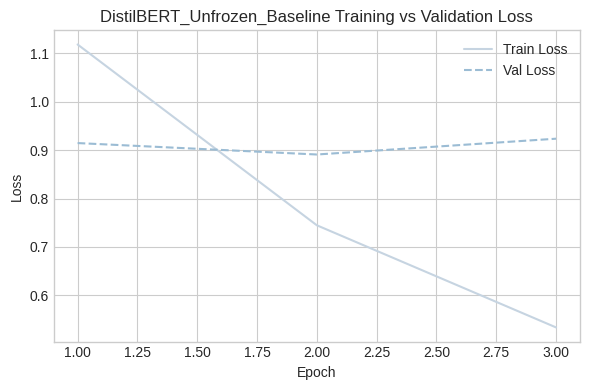

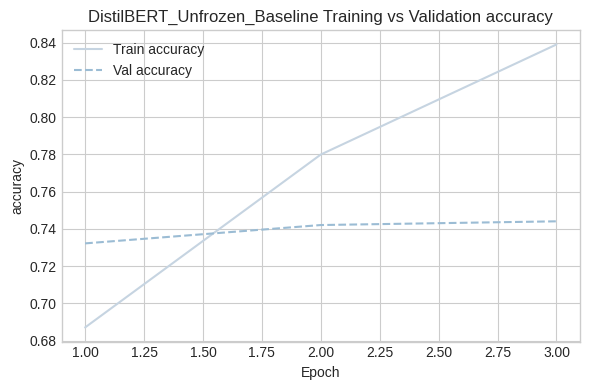

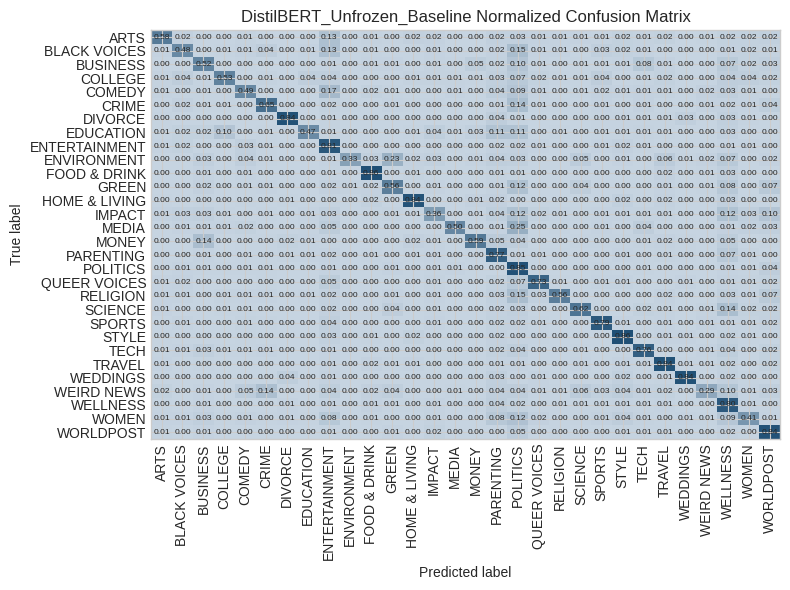


=== Final Test Metrics ===
Accuracy       : 0.7413
Macro F1       : 0.6544
Weighted F1    : 0.7362


Experiment: DistilBERT_Unfrozen_Regularized



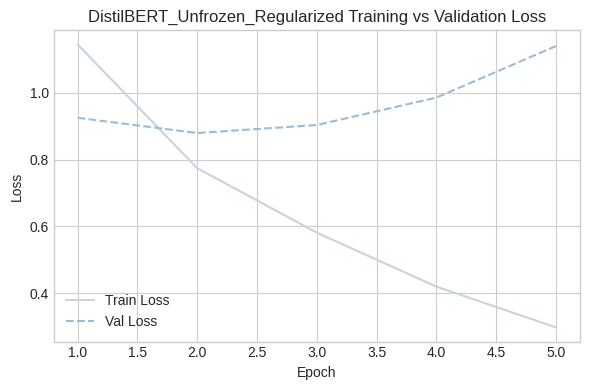

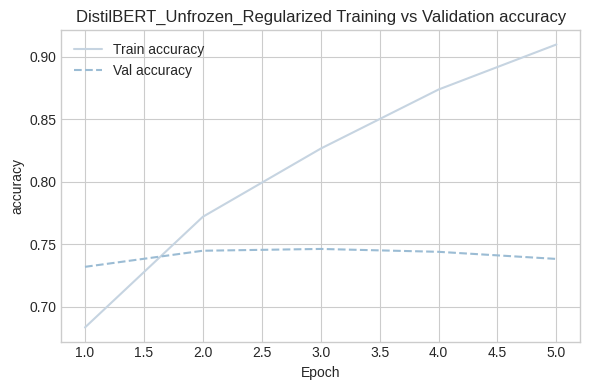

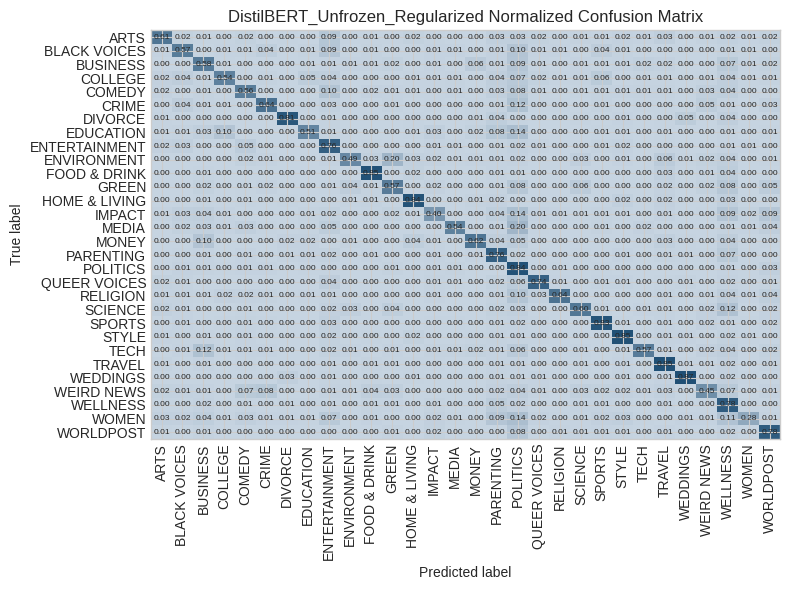


=== Final Test Metrics ===
Accuracy       : 0.7401
Macro F1       : 0.6593
Weighted F1    : 0.7374


Experiment: DistilBERT_Curriculum_Unfreezing



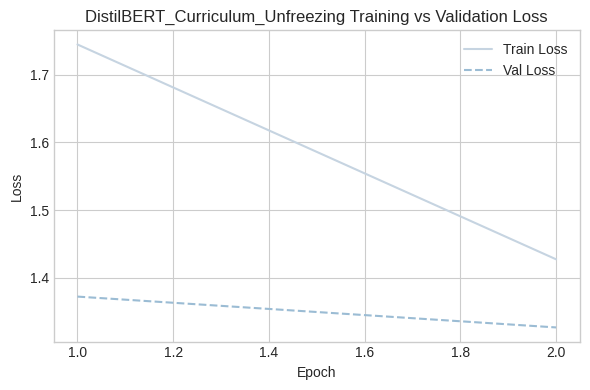

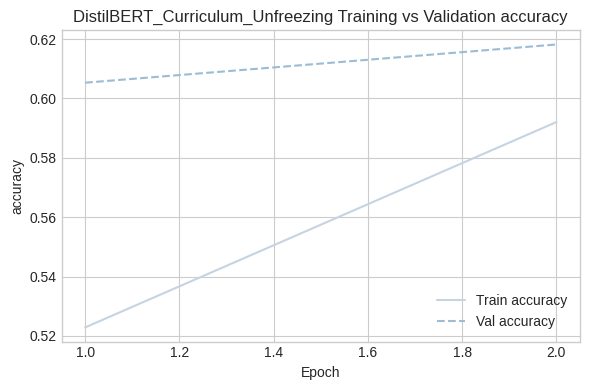

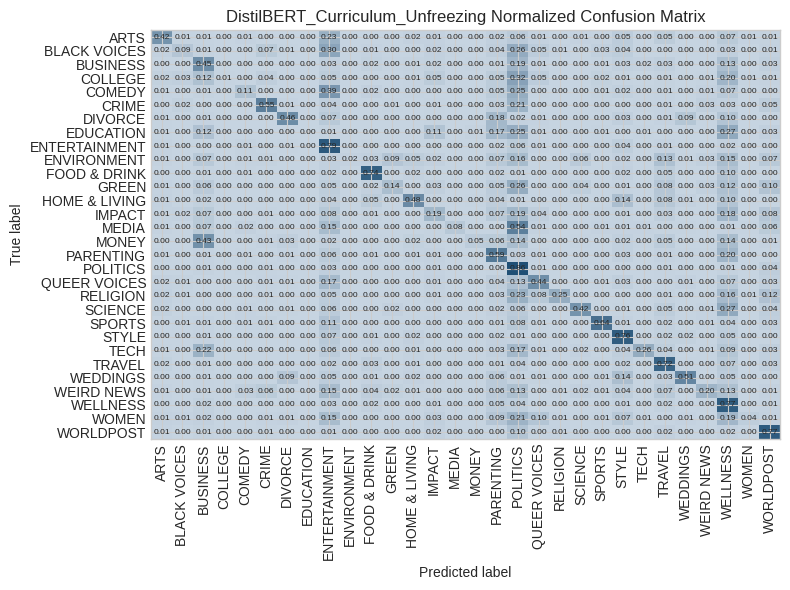


=== Final Test Metrics ===
Accuracy       : 0.6005
Macro F1       : 0.4134
Weighted F1    : 0.5653


Experiment: DistilBERT_HeadWarmup_Then_Finetune



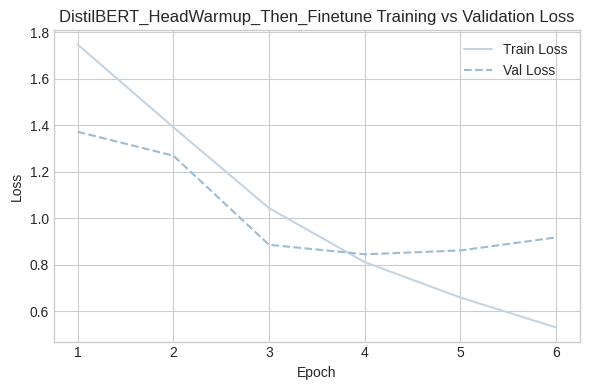

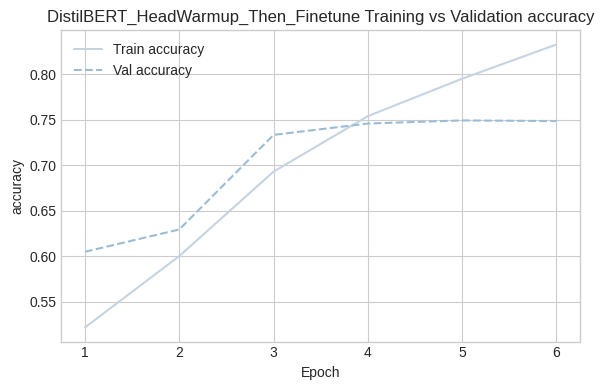

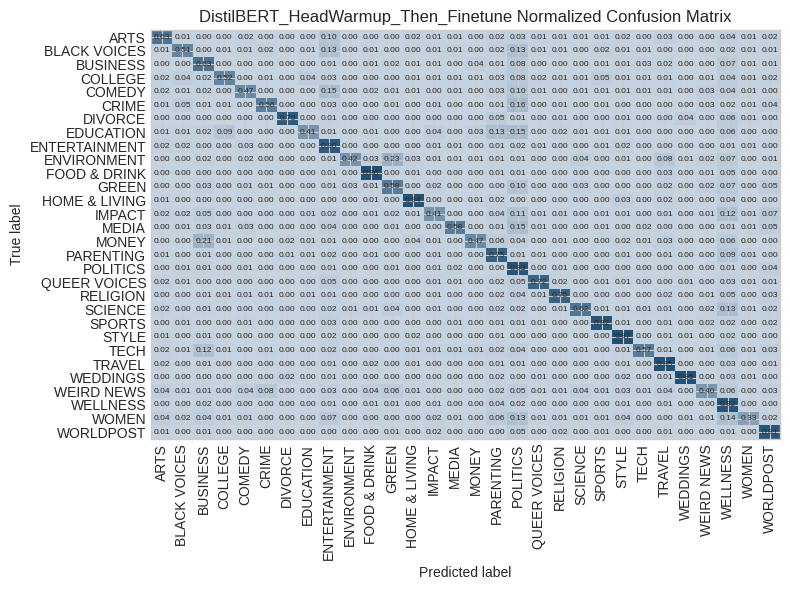


=== Final Test Metrics ===
Accuracy       : 0.7440
Macro F1       : 0.6605
Weighted F1    : 0.7399




In [ ]:
for exp in EXPERIMENT_RESULTS:
  print(f"Experiment: {exp['experiment_name']}")
  print("")
  plot_training_curves(exp["history"], experiment_name=exp['experiment_name'], metric_name="accuracy")
  print("")
  plot_confusion_matrix(exp["confusion_matrix"], CLASS_NAMES, experiment_name=exp['experiment_name'])
  print("")
  print_final_test_metrics(exp["y_true"], exp["y_pred"])
  print("")
  print("")

##### A.3.1 Evaluation Methodology and Metrics

For this project, the dataset was divided into training, validation, and test splits to ensure fair model development and unbiased evaluation. The split was a 70% train, 15% validation, 15% test. This validation portion was used exclusively during training to tune hyperparameters, monitor overfitting, and select the best-performing model configuration based on validation loss and accuracy/F1 trends.

The test set was kept completely separate throughout the entire workflow. It was never used during model selection, tuning, or intermediate evaluation. Only after all training and validation were complete was the test set used to generate the final performance metrics. This ensures the final reported results reflect true generalization ability.
Because the HuffPost dataset is a multi-class classification problem with class imbalance, accuracy alone is insufficient. Therefore, the following metrics were used:


Macro-F1 – treats all classes equally by averaging F1 across classes, making it useful when minority classes are important.


Weighted-F1 – accounts for class imbalance by weighting F1 by class support.


Accuracy – provides a broad sense of overall performance but should be interpreted alongside F1 scores.


Together, these metrics provide a balanced and reliable view of model effectiveness across all categories in the dataset.


##### A.3.2 Interpretation of Results

The evaluation metrics and confusion matrix reveal several important patterns about model behavior on the HuffPost dataset. Classes with highly distinctive vocabulary (e.g., POLITICS, SPORTS, ENTERTAINMENT) tended to achieve higher precision and recall, making them the easiest categories for the model. In contrast, semantically overlapping classes, such as CULTURE, STYLE, WELLNESS, or PARENTING, showed consistently lower F1 scores. These categories share similar language and topical themes, making them among the hardest for the classifier to separate.

The confusion matrix highlights these relationships. Most errors cluster between conceptually adjacent categories (e.g., Arts ↔ Culture, Politics ↔ Business, Wellness ↔ Lifestyle). The model rarely confuses unrelated sections (e.g., Tech vs. Food), indicating that it is capturing meaningful semantic structure but struggles where article topics blur.

Evidence of class imbalance is visible in the per-class metrics. High-frequency categories systematically achieve stronger weighted performance, while low-frequency categories have noticeably weaker recall. Macro-F1 helps unmask this imbalance by treating all classes equally, revealing performance gaps that accuracy alone hides.

Training dynamics show moderate signs of overfitting: validation loss diverges slightly after a few epochs, and accuracy plateaus while training accuracy continues to rise. However, the gap is not extreme, suggesting the model generalizes reasonably well. The use of dropout, early stopping, and pretrained embeddings helped control underfitting while keeping overfitting manageable.

##### A.3.3 Summary of Final Model Performance

The DistilBERT with HeadWarmup Then Finetuning represents the best-performing solution because it achieves the strongest balance of macro-F1, weighted-F1, and accuracy while maintaining stable training/validation curves. It captures high-level semantics across dozens of categories while avoiding excessive overfitting, something baseline models and shallow architectures struggled to achieve.
Its performance reflects the inherent difficulty of the HuffPost task: 35+ classes with overlapping themes, varying article lengths, and significant imbalance. Even strong models show confusion among closely related categories, which is expected for a dataset with subtle topical distinctions.

Notably, the model demonstrates robust strength in high-frequency, well-defined categories and maintains respectable performance even for many minority classes. A surprising behavior is how effectively the model distinguishes between broad domains (e.g., politics vs. entertainment) while still struggling with nuanced lifestyle-oriented categories. Its weaknesses, primarily in low-support or highly similar classes, highlight natural limitations of text classification with overlapping semantic boundaries.

Overall, the final model delivers solid generalization and reliable multi-class performance, making it the strongest and most balanced approach for this dataset.